Complete the exercises below For **Assignment #2**.

First, load the `Tidyverse` package which imports data visualization and wrangling libraries that we need.

In [1]:
# uncomment the code below and execute this cell
library('tidyverse')

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Data visualization

Let's work with the [Palmer Penguins data](https://allisonhorst.github.io/palmerpenguins/).

In [2]:
# uncomment the code below and execute this cell
library('palmerpenguins')
glimpse(penguins)


Attaching package: ‘palmerpenguins’


The following objects are masked from ‘package:datasets’:

    penguins, penguins_raw




Rows: 344
Columns: 8
$ species           <fct> Adelie, Adelie, Adelie, Adelie, Adelie, Adelie, Adel…
$ island            <fct> Torgersen, Torgersen, Torgersen, Torgersen, Torgerse…
$ bill_length_mm    <dbl> 39.1, 39.5, 40.3, NA, 36.7, 39.3, 38.9, 39.2, 34.1, …
$ bill_depth_mm     <dbl> 18.7, 17.4, 18.0, NA, 19.3, 20.6, 17.8, 19.6, 18.1, …
$ flipper_length_mm <int> 181, 186, 195, NA, 193, 190, 181, 195, 193, 190, 186…
$ body_mass_g       <int> 3750, 3800, 3250, NA, 3450, 3650, 3625, 4675, 3475, …
$ sex               <fct> male, female, female, NA, female, male, female, male…
$ year              <int> 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007, 2007…


We now have a data frame called `penguins` available. Use this table for the following exercises.

### Bar chart

In the cell below make a bar chart that shows how many penguins are in the data from each island. Encode the penguin species as the `fill` attribute of the bars.

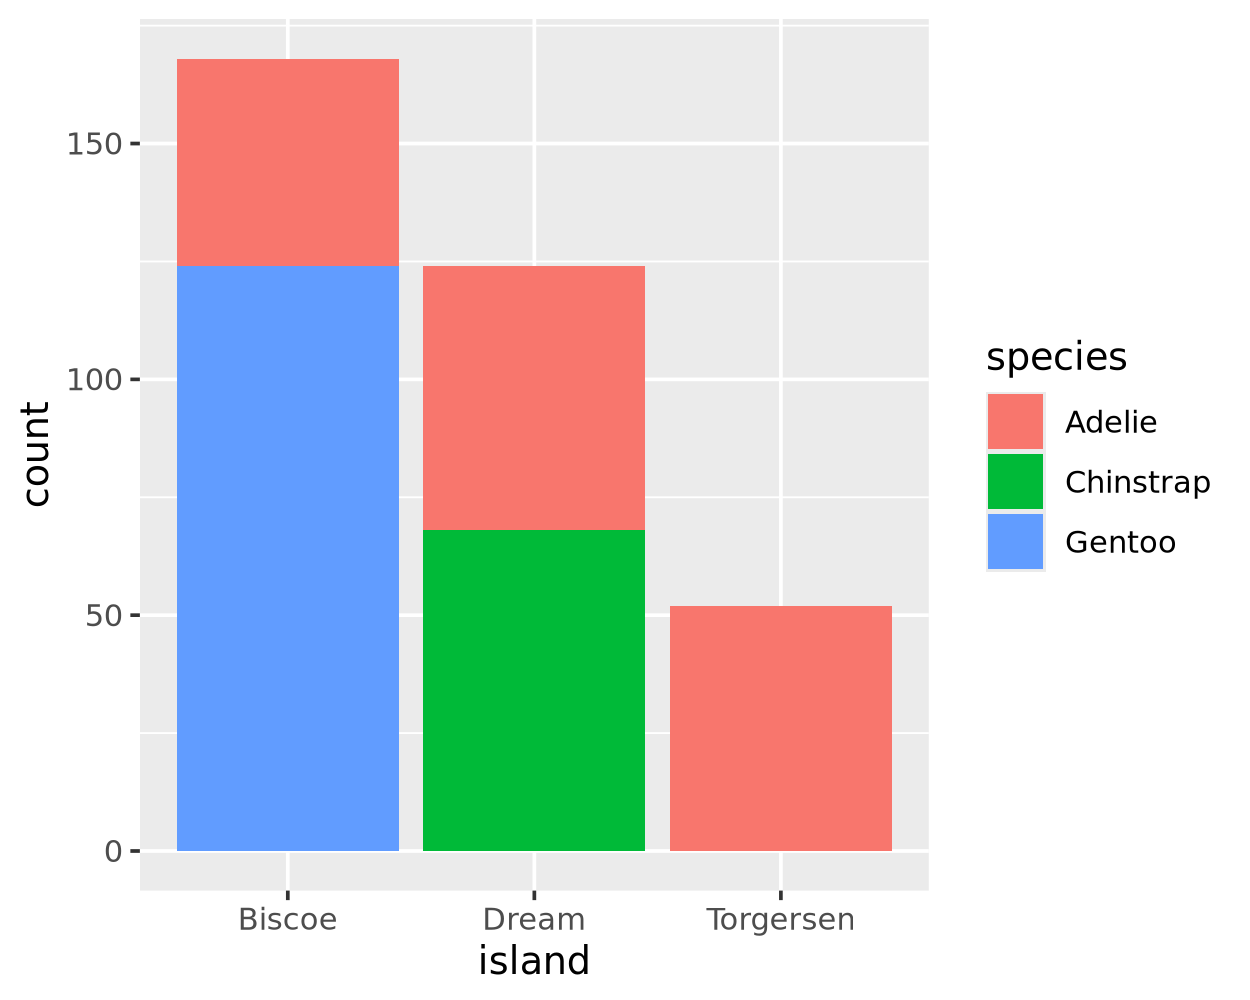

In [3]:
ggplot( data = penguins, aes( x = island, fill = species)) + geom_bar()

**In which islands were *Adelie* penguins observed?** Answer using a [markdown list](https://www.markdownguide.org/basic-syntax/#lists-1) in the cell below. 

⚠️ Remember to switch the cell type to `Markdown`.

Adelie penguins were observed in all three of the islands. 

### Scatter chart

Make a scatter chart of bill depth versus bill length. Color the points by penguin species. Add a `scale` modification to your chart to adjust the color palette (e.g. add `scale_color_brewer(palette = "Set2")`).

Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_point()`).”


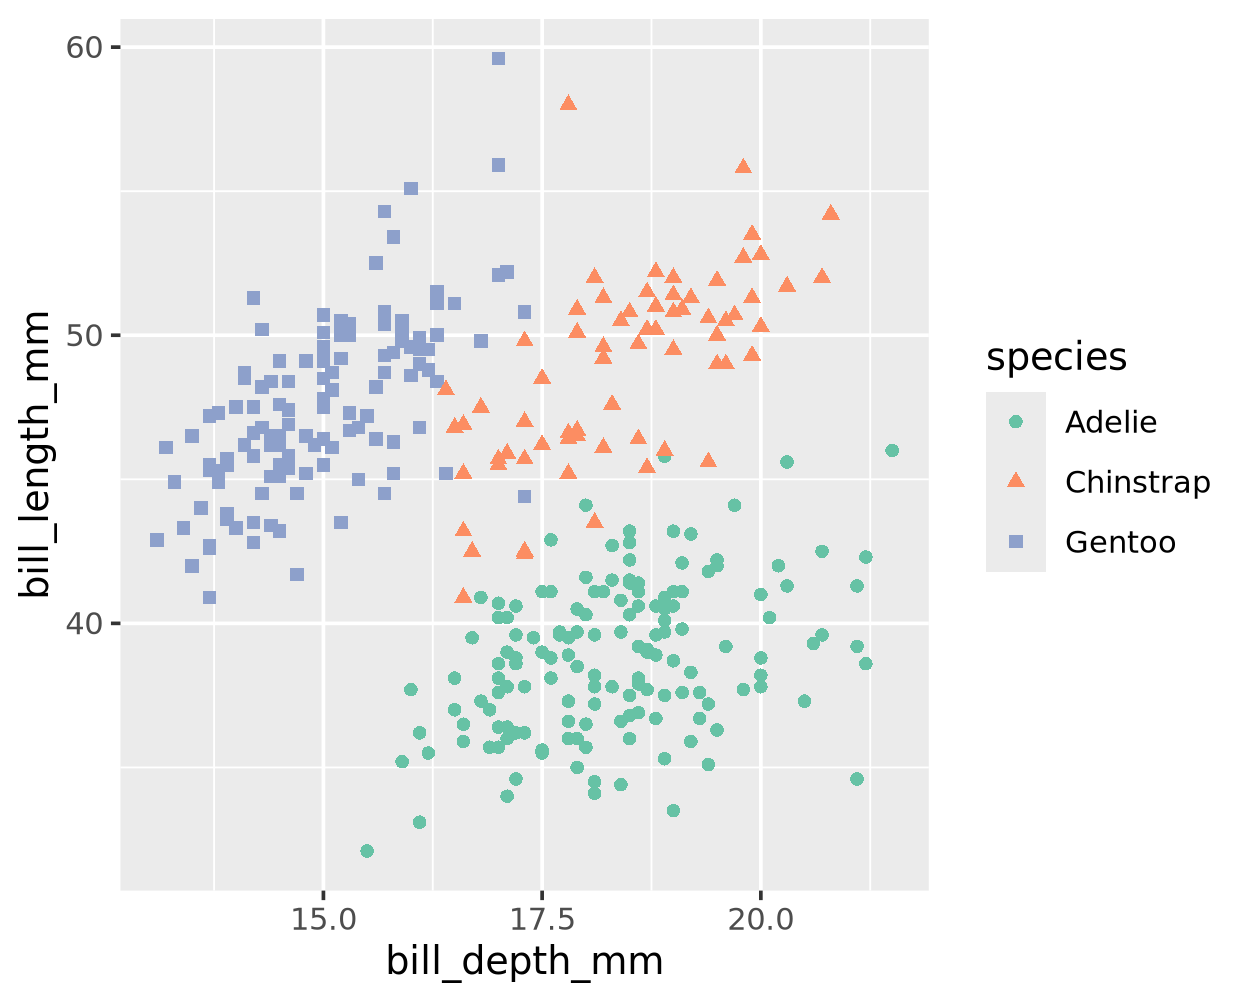

In [4]:
ggplot( data = penguins, mapping = aes(x = bill_depth_mm, y = bill_length_mm)) + geom_point(aes(color = species, shape = species)) + scale_color_brewer(palette = "Set2")

### Histogram

Make a histogram of penguin body mass. 
- Facet your chart by the `sex` column using the `facet_wrap` function and setting the `ncol` parameter to `1`.
- In your `geom_histogram` layer, set the `position` argument to `"identity"` and set `alpha`to a value between `0` and `1`.
- Map penguin species to the `fill` property.
- Adjust the `fill` scale palette similarly to how we adjusted the `color` scale palette above. I.e. change to the [ColorBrewer](https://colorbrewer2.org/) `"Set2"` palette.

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.
Warning message:
“Removed 2 rows containing non-finite outside the scale range (`stat_bin()`).”


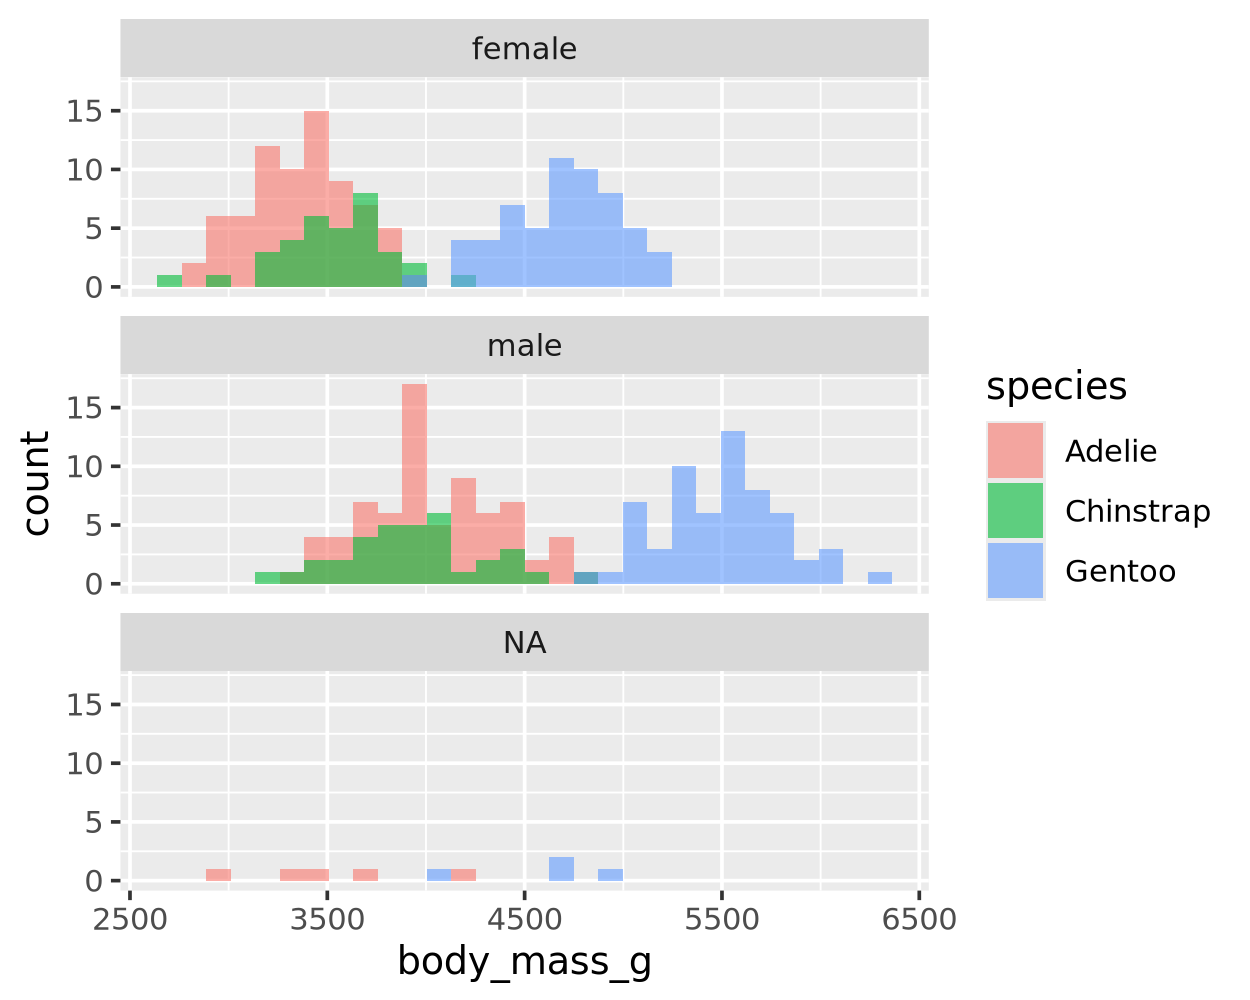

In [5]:
ggplot( data = penguins, aes(x = body_mass_g, fill = species)) + geom_histogram(alpha = 0.6, position = "identity") + facet_wrap(~sex, ncol = 1) + scale_color_brewer(palette = "Set2")

What happens when you don't have `position = "identity"` in your `geom_histogram` layer? Answer below in a `Markdown` cell.

Without the position = "identity" code the bars for each species will stack on top of each other and it will be difficult to compare the total amount in each bin for each species. With it enabled, we can see the three histograms all on top of each other and starting at count = 0. With this position setting, that is also why we choose an alpha < 1, so that the bars are all transparent.

## Data wrangling

First we are going to bring in a data set to practice with called `txhousing`. You can find some information about `txhousing` [here](https://ggplot2.tidyverse.org/reference/txhousing.html).

In [6]:
# uncomment the next two lines and execute this cell
data(txhousing)
glimpse(txhousing)

Rows: 8,602
Columns: 9
$ city      <chr> "Abilene", "Abilene", "Abilene", "Abilene", "Abilene", "Abil…
$ year      <int> 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, 2000, …
$ month     <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 2, 3, 4, 5, 6, 7, …
$ sales     <dbl> 72, 98, 130, 98, 141, 156, 152, 131, 104, 101, 100, 92, 75, …
$ volume    <dbl> 5380000, 6505000, 9285000, 9730000, 10590000, 13910000, 1263…
$ median    <dbl> 71400, 58700, 58100, 68600, 67300, 66900, 73500, 75000, 6450…
$ listings  <dbl> 701, 746, 784, 785, 794, 780, 742, 765, 771, 764, 721, 658, …
$ inventory <dbl> 6.3, 6.6, 6.8, 6.9, 6.8, 6.6, 6.2, 6.4, 6.5, 6.6, 6.2, 5.7, …
$ date      <dbl> 2000.000, 2000.083, 2000.167, 2000.250, 2000.333, 2000.417, …


Write a code chunk to remove the inventory variable. Save the results in a data frame called `txhousing`. Use `glimpse` or `head` to confirm you have removed the variable.

In [7]:
txhousing$inventory <- NULL

head(txhousing)

city,year,month,sales,volume,median,listings,date
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Abilene,2000,1,72,5380000,71400,701,2000.000
Abilene,2000,2,98,6505000,58700,746,2000.083
Abilene,2000,3,130,9285000,58100,784,2000.167
Abilene,2000,4,98,9730000,68600,785,2000.250
Abilene,2000,5,141,10590000,67300,794,2000.333
Abilene,2000,6,156,13910000,66900,780,2000.417


Make a data set called `dallas_sub` that includes data only from the city of Dallas in 2012 & 2013.

In [8]:

dallas_sub <- txhousing |> filter(city == "Dallas", year %in% c(2012, 2013))

head(dallas_sub)

city,year,month,sales,volume,median,listings,date
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Dallas,2012,1,2555,509458081,150800,16721,2012.000
Dallas,2012,2,3085,634067291,157100,17173,2012.083
Dallas,2012,3,4068,898320563,167300,17433,2012.167
Dallas,2012,4,4291,983333297,168700,17632,2012.250
Dallas,2012,5,5004,1175419749,175100,17726,2012.333
Dallas,2012,6,5196,1209024869,177900,17587,2012.417


Add a column to the `dallas_sub` data set called `prct_sold` that calculates the percentage of listings that were sold (`sales/listings * 100`). Be sure to save the results also as a data frame called `dallas_sub`.

In [9]:
dallas_sub <- mutate(dallas_sub, prct_sold = sales/listings * 100)
head(dallas_sub)

city,year,month,sales,volume,median,listings,date,prct_sold
<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Dallas,2012,1,2555,509458081,150800,16721,2012.000,15.28019
Dallas,2012,2,3085,634067291,157100,17173,2012.083,17.96425
Dallas,2012,3,4068,898320563,167300,17433,2012.167,23.33505
Dallas,2012,4,4291,983333297,168700,17632,2012.250,24.33643
Dallas,2012,5,5004,1175419749,175100,17726,2012.333,28.22972
Dallas,2012,6,5196,1209024869,177900,17587,2012.417,29.54455


Calculate the average percentage of listings that were sold in Dallas in each month of the year based on your `dallas_sub` data set. Save the results of the calculation in an data frame called `dallas_summary`.

In [10]:
dallas_summary <- dallas_sub %>% group_by(month) %>% summarise(avg_prct_sold = mean(prct_sold))
head(dallas_summary)

month,avg_prct_sold
<int>,<dbl>
1,20.54462
2,23.47328
3,32.24472
4,34.46954
5,38.20168
6,37.19150


Use `slice_max` to see the top 3 months with the greatest average percentage of listings sold from `dallas_summary`. You do not need to save the results.

In [11]:
dallas_summary %>% slice_max(order_by = avg_prct_sold, n = 3)

month,avg_prct_sold
<int>,<dbl>
8,38.51543
5,38.20168
6,37.19150


Run the following code chunk. Study the code, and the output. Explain in your own words what this code chunk calculated.

In [12]:
txhousing |>
   filter(year == 2012 | year == 2013, city == "Dallas") |>
   mutate(prct_sold = sales/listings *100) |>
   group_by(month) |>
   summarize(mean_prct_sold = mean(prct_sold)) |>
   slice_max(mean_prct_sold, n = 3)

month,mean_prct_sold
<int>,<dbl>
8,38.51543
5,38.20168
6,37.19150


Going line by line:
 Open the txhousing dataframe.
 Filter the dataframe so that only listings in the city of Dallas are used and also are only from the year 2012 or 2013.
 Add in a new column called prct_sold that calculates the percent of sales made in relation to the total number of listings.
 Group the data by month (allows for further calculations to be done via this grouping).
 Calculate the average percentage sold by month from our newly inserted column.
 Return the 3 highest values from the calculation in the line above - providing the 3 months where the most sales were made relative to total listings. 